# Task 3: Controlled Clinical Trial Strategy (ε-Greedy)
**Group Number:** G = 225  
**Assignment:** DRL Semester 2 – Phase #1 (MAB)  
**Strategy:** With probability ε, explore randomly; with probability 1-ε, exploit the current best-performing medicine.  
**Sensitivity Analysis:** ε = 0.10 (10%), ε = 0.01 (1%), ε = 0.50 (50%)

In [1]:
# ─────────────────────────────────────────────────────────────────
# CELL 0 – Library Imports
# ─────────────────────────────────────────────────────────────────

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# ─────────────────────────────────────────────────────────────────
# CELL 1 – Restore Group Configuration & Reproducibility Seeds
#
# Loads the group configuration saved by Task 1 (group_config.json)
# and re-seeds the random engine to the same G=225 value so that
# simulate_treatment() produces reproducible Bernoulli draws.
# ─────────────────────────────────────────────────────────────────

# ── Locate the data directory relative to this notebook ──────────
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR     = os.path.join(NOTEBOOK_DIR, "data")
CONFIG_PATH  = os.path.join(DATA_DIR, "group_config.json")
PARQUET_PATH = os.path.join(DATA_DIR, "df_base.parquet")

# ── Load configuration ────────────────────────────────────────────
with open(CONFIG_PATH, "r") as f:
    cfg = json.load(f)

G      = cfg["G"]
K      = cfg["K"]
TRUE_P = cfg["TRUE_P"]

# ── Re-seed for reproducibility ───────────────────────────────────
np.random.seed(G)

print("Configuration restored from group_config.json")
print(f"  G (Group Number)              : {G}")
print(f"  K (Number of Medicines/Arms)  : {K}")
print(f"  TRUE_P (Hidden Probabilities) : {TRUE_P}")

Configuration restored from group_config.json
  G (Group Number)              : 225
  K (Number of Medicines/Arms)  : 5
  TRUE_P (Hidden Probabilities) : [0.61, 0.68, 0.75, 0.4, 0.47]


In [3]:
# ─────────────────────────────────────────────────────────────────
# CELL 2 – Load df_base from Parquet
#
# Reads the clean base DataFrame persisted by Task 1.
# patient_id is restored as the index to match the original schema.
# ─────────────────────────────────────────────────────────────────

df_base = pd.read_parquet(PARQUET_PATH)
df_base.set_index("patient_id", inplace=True)

print(f"df_base loaded: {df_base.shape[0]} rows × {df_base.shape[1]} columns")
print(f"Columns        : {list(df_base.columns)}")
print()
print("First 5 rows (dynamic columns should be NaN):")
print(df_base.head())

df_base loaded: 1000 rows × 4 columns
Columns        : ['severity_score', 'assigned_medicine', 'clinical_outcome', 'utility_score']

First 5 rows (dynamic columns should be NaN):
            severity_score  assigned_medicine  clinical_outcome  utility_score
patient_id                                                                    
0                        1                NaN               NaN            NaN
1                        2                NaN               NaN            NaN
2                        3                NaN               NaN            NaN
3                        4                NaN               NaN            NaN
4                        5                NaN               NaN            NaN


In [4]:
# ─────────────────────────────────────────────────────────────────
# CELL 3 – Environmental Feedback Engine: simulate_treatment()
#
# Identical definition to Task 1 & 2. Redefined here so this
# notebook is fully self-contained when run independently.
# ─────────────────────────────────────────────────────────────────

def simulate_treatment(medicine_idx: int, severity_score: int) -> tuple:
    """
    Simulate administering a medicine to a patient.

    Returns
    -------
    (clinical_outcome, utility_score) : tuple(int, float)
      clinical_outcome – 1 if recovered, 0 otherwise (Bernoulli trial)
      utility_score    – severity-penalised reward: outcome × (1 − sev/10)
    """
    success_prob     = TRUE_P[medicine_idx]
    clinical_outcome = int(np.random.binomial(1, success_prob))
    utility_score    = clinical_outcome * (1 - severity_score / 10)
    return (clinical_outcome, utility_score)

print("simulate_treatment() defined.")

simulate_treatment() defined.


In [5]:
# ─────────────────────────────────────────────────────────────────
# CELL 4 – ε-Greedy Algorithm: run_epsilon_greedy()
#
# Algorithm outline
# -----------------
# For every incoming patient, flip a weighted coin:
#   With probability ε   → EXPLORE: select a random medicine uniformly.
#   With probability 1-ε → EXPLOIT: select the medicine with the
#                           highest empirical success rate so far.
#
# Empirical success rate Q[k] = success_counts[k] / pull_counts[k]
#   when pull_counts[k] > 0, otherwise 0.
#
# Each call resets np.random.seed(seed) so that runs at different ε
# values all start from the same RNG state and are directly
# comparable in the sensitivity analysis.
#
# Statistics updated using clinical_outcome only (binary 0/1).
# Cumulative reward tracked using utility_score.
# ─────────────────────────────────────────────────────────────────

def run_epsilon_greedy(epsilon: float, seed: int = None) -> tuple:
    """
    Run the ε-Greedy bandit strategy for 1000 patients.

    Parameters
    ----------
    epsilon : float  – exploration probability (0 ≤ ε ≤ 1)
    seed    : int    – RNG seed for reproducibility; defaults to G

    Returns
    -------
    df             : pd.DataFrame  – fully populated patient records
    history        : list[float]   – cumulative utility at each step
    success_counts : np.ndarray    – total successes per medicine
    pull_counts    : np.ndarray    – total pulls per medicine
    """
    if seed is None:
        seed = G

    # ── Reset RNG for this run (ensures comparability across ε) ───
    np.random.seed(seed)

    # ── Working copy of the base DataFrame ───────────────────────
    df = df_base.copy(deep=True)

    # ── Bandit statistics accumulators ───────────────────────────
    success_counts = np.zeros(K, dtype=float)
    pull_counts    = np.zeros(K, dtype=float)

    # ── Reward tracking ───────────────────────────────────────────
    cumulative_reward = 0.0
    history           = []

    # ── Main simulation loop ──────────────────────────────────────
    for patient_id in range(1000):

        severity = int(df.at[patient_id, "severity_score"])

        # ── ε-Greedy selection ────────────────────────────────────
        if np.random.random() < epsilon:
            # Explore: pick a random medicine uniformly at random
            chosen_medicine = int(np.random.randint(K))
        else:
            # Exploit: pick arm with highest empirical success rate
            # Arms never pulled yet are treated as Q=0
            Q = np.where(pull_counts > 0,
                         success_counts / pull_counts,
                         0.0)
            chosen_medicine = int(np.argmax(Q))

        # ── Simulate treatment and collect feedback ───────────────
        clinical_outcome, utility_score = simulate_treatment(chosen_medicine, severity)

        # ── Update bandit statistics (binary clinical_outcome) ────
        success_counts[chosen_medicine] += clinical_outcome
        pull_counts[chosen_medicine]    += 1

        # ── Populate df row ───────────────────────────────────────
        df.at[patient_id, "assigned_medicine"] = chosen_medicine
        df.at[patient_id, "clinical_outcome"]  = clinical_outcome
        df.at[patient_id, "utility_score"]     = utility_score

        # ── Accumulate reward ─────────────────────────────────────
        cumulative_reward += utility_score
        history.append(cumulative_reward)

    return df, history, success_counts, pull_counts

print("run_epsilon_greedy() defined.")

run_epsilon_greedy() defined.


In [6]:
# ─────────────────────────────────────────────────────────────────
# CELL 5 – Sensitivity Analysis: Three ε Runs
#
# Runs the ε-Greedy algorithm independently for each exploration
# probability.  Each call to run_epsilon_greedy() resets the RNG
# to G before starting so results are directly comparable.
# ─────────────────────────────────────────────────────────────────

EPSILONS = [0.10, 0.01, 0.50]

results = {}

print("Running sensitivity analysis...")
print()

for eps in EPSILONS:
    df_run, hist, s_counts, p_counts = run_epsilon_greedy(epsilon=eps, seed=G)
    results[eps] = {
        "df"             : df_run,
        "history"        : hist,
        "success_counts" : s_counts,
        "pull_counts"    : p_counts,
    }
    print(f"  ε = {eps:.2f}  →  Final cumulative reward = {hist[-1]:.4f}  "
          f"| Total pulls = {int(p_counts.sum())}")

print()
print("All 3 sensitivity runs complete.")

Running sensitivity analysis...



C:\Users\rohit\AppData\Local\Temp\ipykernel_20084\2657161519.py:68: RuntimeWarning: invalid value encountered in divide
  success_counts / pull_counts,


  ε = 0.10  →  Final cumulative reward = 482.3000  | Total pulls = 1000
  ε = 0.01  →  Final cumulative reward = 478.0000  | Total pulls = 1000
  ε = 0.50  →  Final cumulative reward = 474.9000  | Total pulls = 1000

All 3 sensitivity runs complete.


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELL 6 – Verification & Output
#
# For each ε value:
#   1. Final cumulative reward.
#   2. Pull counts per medicine and empirical success rates.
#   3. Best arm identified (vs. true optimal arm).
#   4. Transition slice (rows 0–9) for ε = 0.10 run.
# ─────────────────────────────────────────────────────────────────

EPS_LABEL = {0.10: "010", 0.01: "001", 0.50: "050"}
EPS_DESC  = {0.10: "Moderate (10%)", 0.01: "Low (1%)", 0.50: "High (50%)"}

TRUE_OPTIMAL = int(np.argmax(TRUE_P))

print("=" * 60)
print("TASK 3 – ε-GREEDY SENSITIVITY ANALYSIS RESULTS")
print("=" * 60)
print(f"True optimal medicine : {TRUE_OPTIMAL}  (P = {TRUE_P[TRUE_OPTIMAL]:.2f})")
print()

for eps in EPSILONS:
    r  = results[eps]
    sc = r["success_counts"]
    pc = r["pull_counts"]
    Q  = np.where(pc > 0, sc / pc, 0.0)
    best_arm = int(np.argmax(Q))

    print(f"ε = {eps:.2f}  [{EPS_DESC[eps]} exploration]")
    print(f"  Final cumulative reward  : {r['history'][-1]:.4f}")
    print(f"  Pull counts per medicine : {pc.astype(int).tolist()}")
    print(f"  Empirical success rates  : {[round(q, 4) for q in Q.tolist()]}")
    print(f"  Best arm by empirical Q  : Medicine {best_arm}  "
          f"(true P = {TRUE_P[best_arm]:.2f})"
          + ("  ← OPTIMAL" if best_arm == TRUE_OPTIMAL else "  ← SUBOPTIMAL"))
    print()

print("-" * 60)
print("Transition slice – ε = 0.10 run, df.iloc[0:10]")
print("(First 10 patients; mix of exploration and exploitation)")
print("-" * 60)
print(results[0.10]["df"].reset_index().iloc[0:10].to_string(index=False))
print("=" * 60)

TASK 3 – ε-GREEDY SENSITIVITY ANALYSIS RESULTS
True optimal medicine : 2  (P = 0.75)

ε = 0.10  [Moderate (10%) exploration]
  Final cumulative reward  : 482.3000
  Pull counts per medicine : [122, 56, 771, 27, 24]
  Empirical success rates  : [0.5656, 0.6429, 0.7328, 0.2593, 0.5417]
  Best arm by empirical Q  : Medicine 2  (true P = 0.75)  ← OPTIMAL

ε = 0.01  [Low (1%) exploration]
  Final cumulative reward  : 478.0000
  Pull counts per medicine : [420, 3, 572, 2, 3]
  Empirical success rates  : [0.5786, 0.3333, 0.7622, 0.5, 0.0]
  Best arm by empirical Q  : Medicine 2  (true P = 0.75)  ← OPTIMAL

ε = 0.50  [High (50%) exploration]
  Final cumulative reward  : 474.9000
  Pull counts per medicine : [104, 104, 619, 77, 96]
  Empirical success rates  : [0.625, 0.7019, 0.7447, 0.4545, 0.4583]
  Best arm by empirical Q  : Medicine 2  (true P = 0.75)  ← OPTIMAL

------------------------------------------------------------
Transition slice – ε = 0.10 run, df.iloc[0:10]
(First 10 patients; m

In [8]:
# ─────────────────────────────────────────────────────────────────
# CELL 7 – Persist Outputs for Task 5 (Comparative Plots)
#
# Saves three DataFrames and three utility-history arrays so the
# Task 5 notebook can load them alongside outputs from Tasks 2 & 4
# and generate multi-algorithm comparative reward curves.
# ─────────────────────────────────────────────────────────────────

print("Persisting outputs...")
print()

for eps in EPSILONS:
    label        = EPS_LABEL[eps]
    parquet_path = os.path.join(DATA_DIR, f"df_epsilon_greedy_{label}.parquet")
    history_path = os.path.join(DATA_DIR, f"epsilon_greedy_history_{label}.npy")

    results[eps]["df"].reset_index().to_parquet(parquet_path, index=False)
    np.save(history_path, np.array(results[eps]["history"]))

    print(f"ε = {eps:.2f}  df saved      → {parquet_path}")
    print(f"         history saved → {history_path}")
    print()

print("All outputs persisted.")

Persisting outputs...

ε = 0.10  df saved      → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\df_epsilon_greedy_010.parquet
         history saved → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\epsilon_greedy_history_010.npy

ε = 0.01  df saved      → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\df_epsilon_greedy_001.parquet
         history saved → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\epsilon_greedy_history_001.npy

ε = 0.50  df saved      → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\df_epsilon_greedy_050.parquet
         history saved → c:\Users\rohit\OneDrive\Desktop\BITSWILP\2ndSem\DRL\gitcode\SEM2_DRL_ASSIGNMENT_PART1\Phase#1\data\epsilon_greedy_history_050.npy

All outputs persisted.


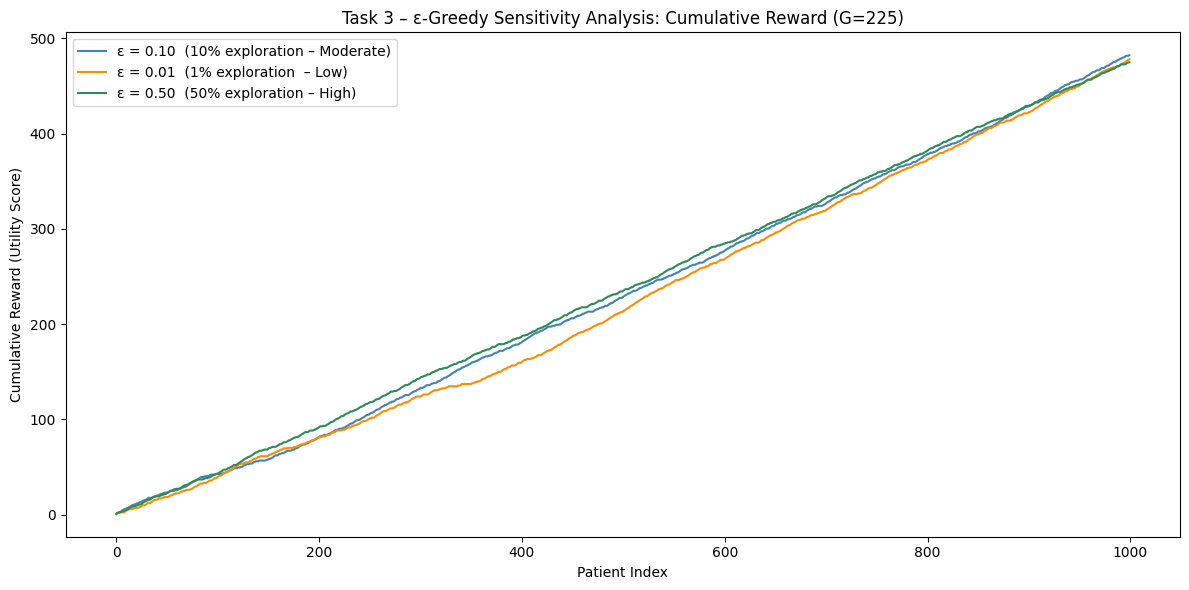

In [9]:
# ─────────────────────────────────────────────────────────────────
# CELL 8 – Sensitivity Analysis Plot
#
# Overlays the cumulative reward curves for all three ε values on
# a single figure so the exploration-exploitation trade-off is
# immediately visible.
#
# Expected pattern:
#   ε = 0.01 – converges fastest but may lock in a suboptimal arm
#              if early pulls were unlucky.
#   ε = 0.10 – balanced; typically identifies the optimal arm and
#              accumulates the highest long-run reward.
#   ε = 0.50 – explores extensively; slope is flatter because 50%
#              of pulls are random and unlikely to be the best arm.
# ─────────────────────────────────────────────────────────────────

COLORS = {0.10: "steelblue", 0.01: "darkorange", 0.50: "seagreen"}
LABELS = {
    0.10: "ε = 0.10  (10% exploration – Moderate)",
    0.01: "ε = 0.01  (1% exploration  – Low)",
    0.50: "ε = 0.50  (50% exploration – High)",
}

plt.figure(figsize=(12, 6))
for eps in EPSILONS:
    plt.plot(results[eps]["history"],
             color=COLORS[eps], linewidth=1.5, label=LABELS[eps])

plt.xlabel("Patient Index")
plt.ylabel("Cumulative Reward (Utility Score)")
plt.title("Task 3 – ε-Greedy Sensitivity Analysis: Cumulative Reward (G=225)")
plt.legend()
plt.tight_layout()
plt.show()